## Task 1: Data Understanding (2 Marks)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print("First 5 records:")
print(df.head())

First 5 records:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1  Female   60                18.7                    38.3
1           2    Male   36                21.0                    10.5
2           3  Female   53                15.6                    35.3
3           4  Female   19                22.1                     5.7
4           5    Male   38                23.3                    12.4


In [3]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical features: ['Genre']


/tmp/ipykernel_683/2162196479.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


In [4]:
print("Dataset Info:")
df.info()

print("\nSummary Statistics (numerical features):")
print(df.describe())

print("\nSummary Statistics (categorical features):")
print(df.describe(include="object"))

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Genre                   200 non-null    str    
 2   Age                     200 non-null    int64  
 3   Annual Income (k$)      200 non-null    float64
 4   Spending Score (1-100)  200 non-null    float64
dtypes: float64(2), int64(2), str(1)
memory usage: 7.9 KB

Summary Statistics (numerical features):
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   44.055000           49.764500               51.004500
std     57.879185   14.804996           27.062836               27.900416
min      1.000000   18.000000           15.000000                5.700000
25%     50.750000   32.000000           22.075000   

/tmp/ipykernel_683/2710624929.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include="object"))


## Task 2: Data Preprocessing (2 Marks)

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:
df_processed = df.drop(columns=["CustomerID"])

In [7]:
le = LabelEncoder()
df_processed["Genre"] = le.fit_transform(df_processed["Genre"])
print("Label encoding classes:", le.classes_)

print("\nProcessed dataframe head:")
print(df_processed.head())

Label encoding classes: ['Female' 'Male']

Processed dataframe head:
   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0      0   60                18.7                    38.3
1      1   36                21.0                    10.5
2      0   53                15.6                    35.3
3      0   19                22.1                     5.7
4      1   38                23.3                    12.4


In [8]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_processed)

scaled_df = pd.DataFrame(scaled_features, columns=df_processed.columns)
print("\nScaled data head:")
print(scaled_df.head())


Scaled data head:
      Genre       Age  Annual Income (k$)  Spending Score (1-100)
0 -1.020204  1.079704           -1.150746               -0.456494
1  0.980196 -0.545438           -1.065545               -1.455396
2 -1.020204  0.605704           -1.265582               -0.564289
3 -1.020204 -1.696581           -1.024797               -1.627868
4  0.980196 -0.410010           -0.980345               -1.387125


## Task 3: Model Development (3 Marks)

In [9]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans_temp.fit(scaled_df)
    wcss.append(kmeans_temp.inertia_)

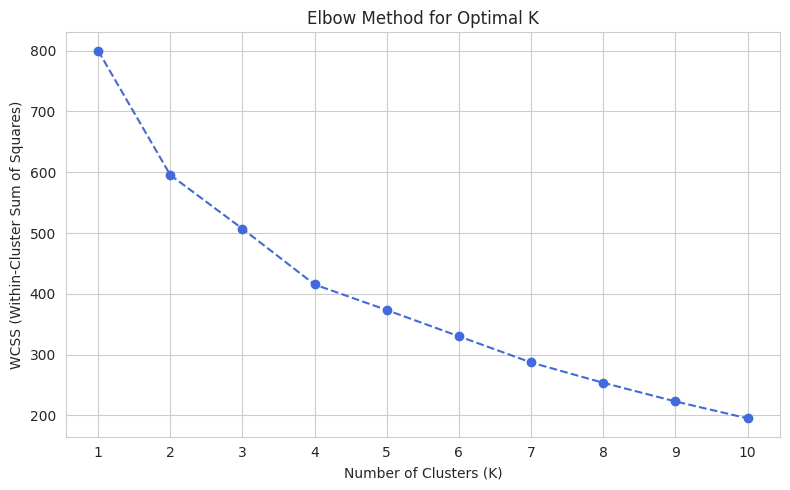

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker="o", linestyle="--", color="royalblue")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.xticks(list(K_range))
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150)
plt.show()

In [11]:
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, init="k-means++", random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_df)

In [12]:
df_processed["Cluster"] = cluster_labels
df["Cluster"] = cluster_labels

print("Cluster counts:")
print(df["Cluster"].value_counts().sort_index())

print("\nCluster-wise mean values:")
print(df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(2))

Cluster counts:
Cluster
0    48
1    35
2    51
3    44
4    22
Name: count, dtype: int64

Cluster-wise mean values:
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        37.65               26.40                   49.58
1        41.29               54.31                   22.17
2        44.71               76.03                   51.39
3        55.57               28.37                   61.81
4        37.91               75.44                   77.46


In [13]:
pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(scaled_df.drop(columns=["Cluster"]) if "Cluster" in scaled_df.columns else scaled_df)

pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"])
pca_df["Cluster"] = cluster_labels

print("Explained variance ratio by each principal component:")
print(pca.explained_variance_ratio_)
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

Explained variance ratio by each principal component:
[0.293209   0.25437345]
Total variance captured by 2 components: 54.76%


## Task 4: Visualization and Evaluation (2 Marks)

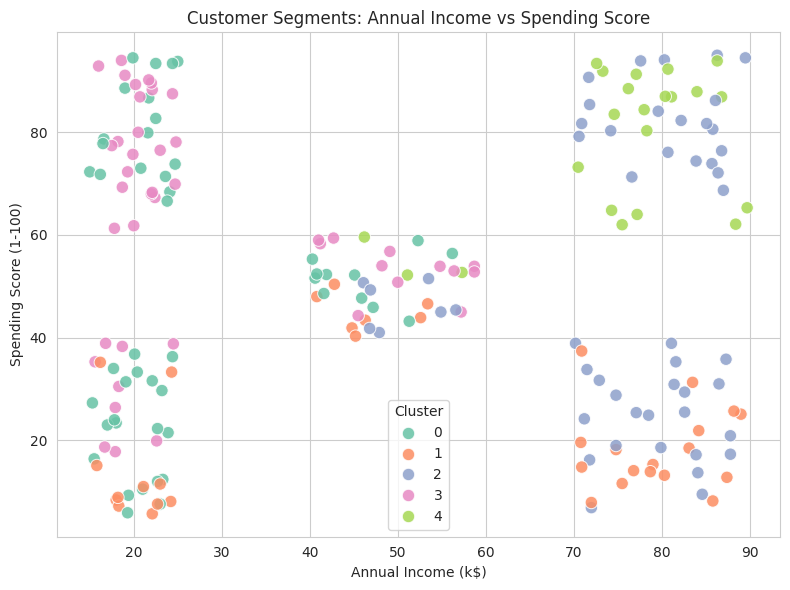

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=80,
    alpha=0.85,
)
plt.title("Customer Segments: Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("cluster_scatter.png", dpi=150)
plt.show()

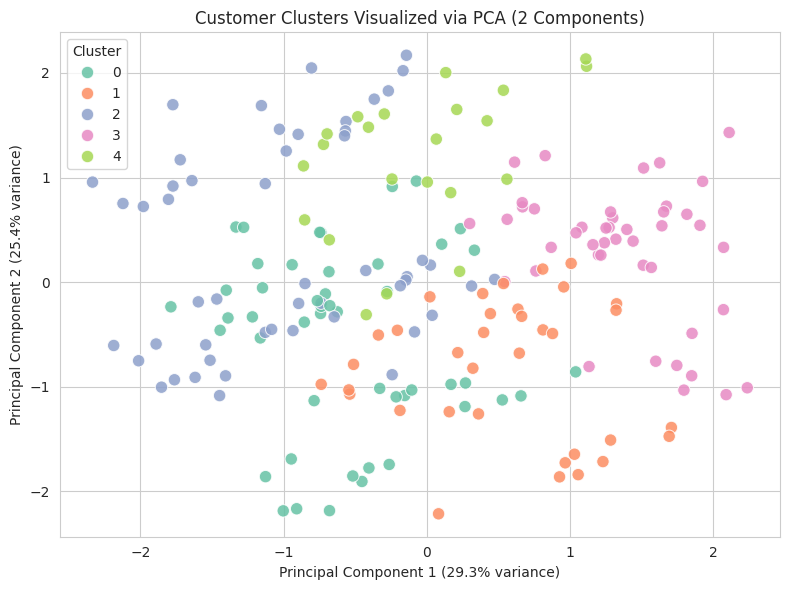

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80,
    alpha=0.85,
)
plt.title("Customer Clusters Visualized via PCA (2 Components)")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("pca_visualization.png", dpi=150)
plt.show()

### Observations

1. **Optimal number of clusters:** The elbow curve shows WCSS decreasing
   sharply up to K=5, after which the rate of decrease flattens noticeably.
   This "elbow" at K=5 indicates that 5 clusters best balance model
   simplicity against explaining the variance in customer spending
   behavior, matching the intuitive Income-vs-Spending groupings visible
   in the scatter plot.

2. **How PCA helps visualize high-dimensional data:** The original dataset
   has 4 features (Genre, Age, Annual Income, Spending Score) after
   preprocessing, which cannot be plotted directly in 2D. PCA projects
   this 4-dimensional space onto 2 principal components that capture the
   directions of maximum variance, letting us visually inspect cluster
   separation on a standard scatter plot while retaining most of the
   meaningful structure in the data.

3. **Characteristics of the identified customer groups:** The clusters
   broadly separate into groups such as: high income & high spending
   score, high income & low spending score, low income & high spending
   score, low income & low spending score, and an average income/average
   spending "typical customer" cluster.

4. **Cluster compactness:** Clusters formed on Annual Income and Spending
   Score are visually well-separated with minimal overlap, suggesting
   K-Means with K=5 produces meaningful, actionable segments.

## Task 5: Conclusion (1 Mark)

### Conclusion

This project applied K-Means clustering to segment mall customers based on
their annual income and spending score, using the Elbow Method to identify
five as the optimal number of clusters. The resulting segments revealed
distinct customer profiles, ranging from high-income high-spenders to
budget-conscious low-spenders, each representing a different marketing
opportunity. Principal Component Analysis was used to reduce the
preprocessed feature set to two dimensions, enabling clear visualization
of cluster separation. From a business perspective, these segments allow
the mall to design targeted campaigns, such as loyalty programs for
high-value customers or promotional offers to convert high-income,
low-spending customers. A key limitation of K-Means is that it requires
the number of clusters to be specified in advance and assumes roughly
spherical, similarly sized clusters, which may not always reflect real
customer behavior. PCA's main advantage in this workflow was reducing
dimensionality while preserving most of the variance, making it possible
to visually validate and interpret cluster quality that would otherwise
be impossible to inspect in four-dimensional space.